DOWNLOADING DATASET
Using Colab cache for faster access to the 'retail-store-inventory-forecasting-dataset' dataset.
Dataset path:
/kaggle/input/retail-store-inventory-forecasting-dataset

CSV files found:
/kaggle/input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv

Using file:
/kaggle/input/retail-store-inventory-forecasting-dataset/retail_store_inventory.csv

DATASET INFORMATION

Shape:
(73100, 15)

Columns:
['date', 'store_id', 'product_id', 'category', 'region', 'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast', 'price', 'discount', 'weather_condition', 'holiday/promotion', 'competitor_pricing', 'seasonality']

First 5 rows:


,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,demand_forecast,price,discount,weather_condition,holiday/promotion,competitor_pricing,seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer



IDENTIFIED COLUMNS
Date       : date
Sales      : units_sold
Product    : product_id
Store      : store_id
Category   : category
Price      : price
Inventory  : inventory_level
Discount   : discount
Promotion  : None
Holiday    : None
Weather    : weather_condition

Records after cleaning:
73100

Number of time series:
100

Records after aggregation:
73100

Creating lag features...

Records after historical feature creation:
70300

FINAL DATASET
Total records: 70300
Total features: 43

Feature list:
- year
- month
- day
- day_of_week
- week_of_year
- quarter
- is_weekend
- month_sin
- month_cos
- day_of_week_sin
- day_of_week_cos
- lag_1
- lag_2
- lag_3
- lag_7
- lag_14
- lag_21
- lag_28
- rolling_mean_3
- rolling_mean_7
- rolling_mean_14
- rolling_mean_28
- rolling_std_3
- rolling_std_7
- rolling_std_14
- rolling_std_28
- rolling_max_3
- rolling_max_7
- rolling_max_14
- rolling_max_28
- ewm_7
- ewm_14
- ewm_28
- momentum_7_1
- momentum_14_7
- price
- inventory_level
- discount
- weat

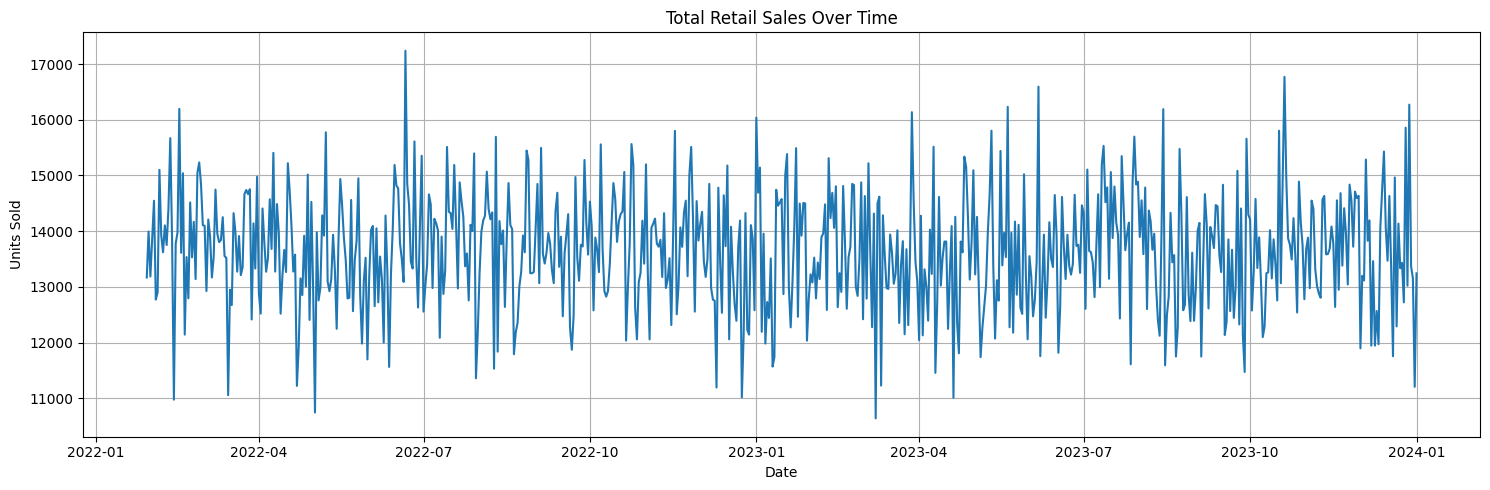

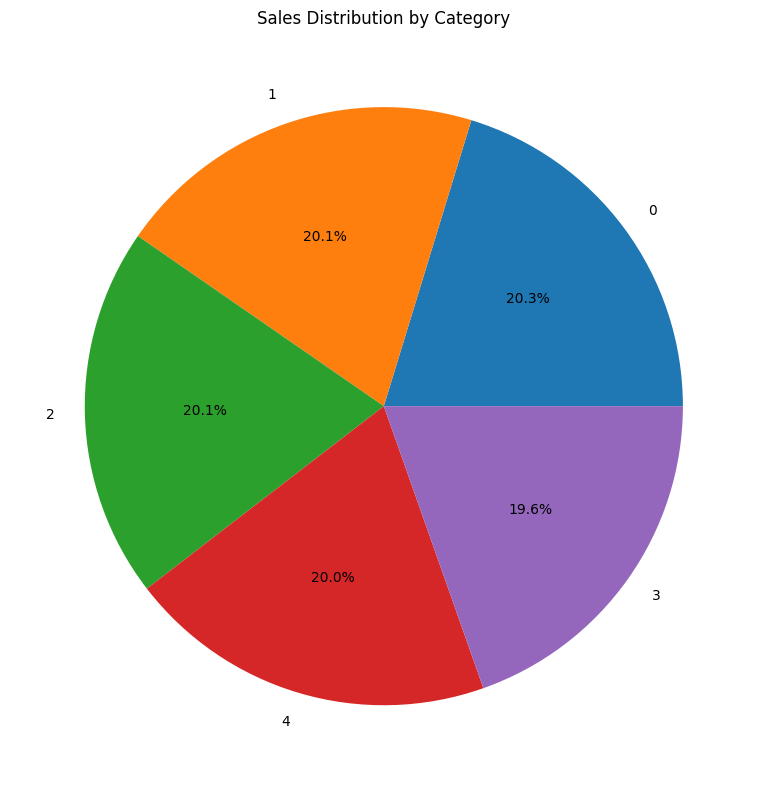


DATE BASED SPLIT
Train records      : 49200
Validation records : 10500
Test records       : 10600

Train ends before:
2023-06-05 00:00:00
Validation ends before:
2023-09-18 00:00:00

BASELINE PERFORMANCE - LAG 7
MAE  : 118.5762
RMSE : 151.9838
R²   : -0.9741

TRAINING XGBOOST
[0]	validation_0-rmse:108.96994
[200]	validation_0-rmse:88.37831
[400]	validation_0-rmse:88.36340
[446]	validation_0-rmse:88.37357

Initial training completed.

VALIDATION PERFORMANCE
MAE  : 68.8057
RMSE : 88.2928
R²   : 0.3503

Best number of estimators:
297

Training final model using Train + Validation data...

FINAL TEST PERFORMANCE
MAE  : 69.0517
RMSE : 88.1464
R²   : 0.3360

IMPROVEMENT VS BASELINE
MAE Improvement: 41.77%
RMSE Improvement: 42.00%


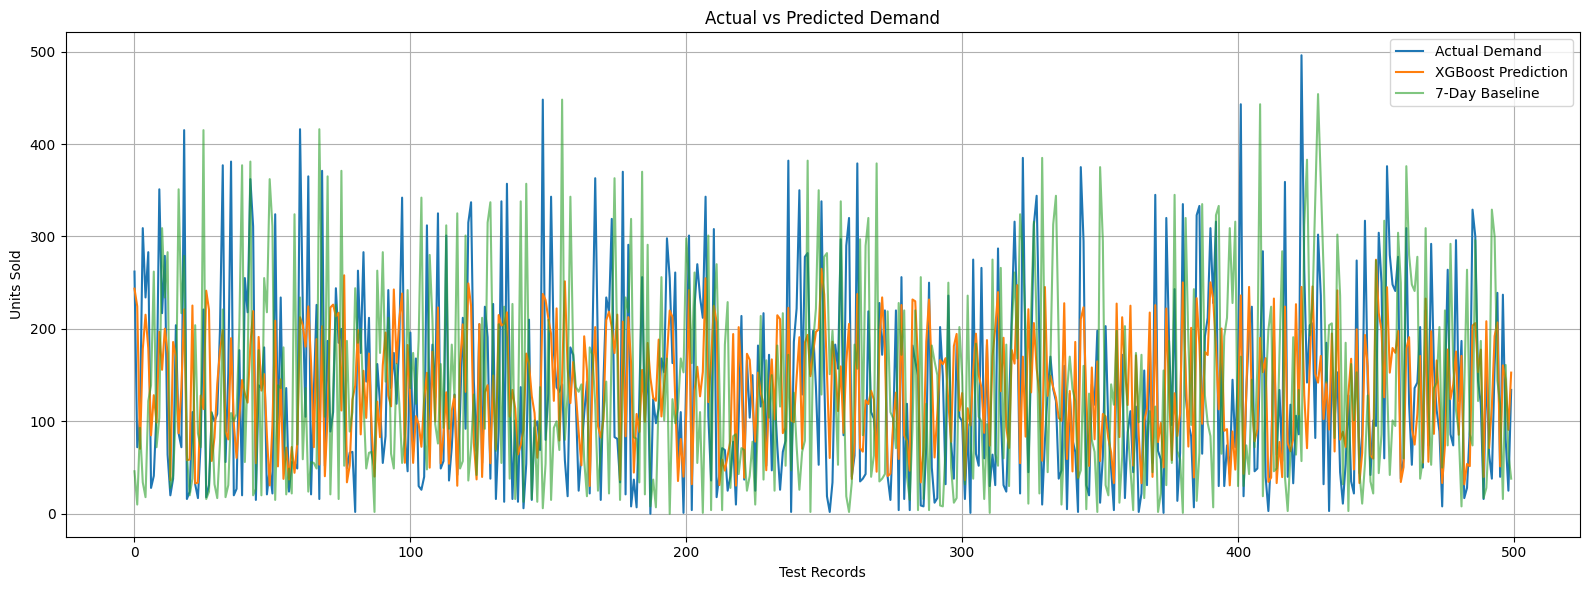


TOP 20 IMPORTANT FEATURES:


,feature,importance
0,inventory_level,0.451003
1,ewm_28,0.015310
2,rolling_std_28,0.014793
3,ewm_14,0.014668
4,rolling_max_3,0.014426
5,month_cos,0.014264
6,rolling_max_7,0.013965
7,rolling_mean_28,0.013956
8,momentum_7_1,0.013925
9,lag_7,0.013891


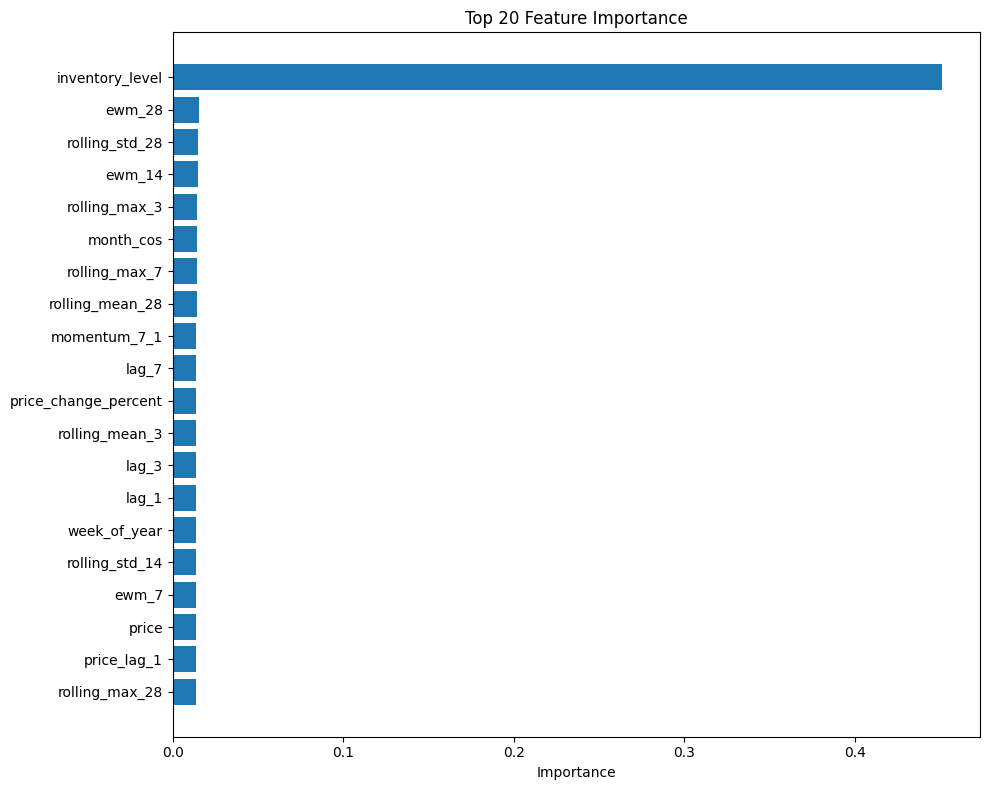



RETAIL DEMAND FORECASTING COMPLETED

DATASET
Total Records Used: 70300
Total Features: 43

BASELINE
MAE  : 118.5762
RMSE : 151.9838
R²   : -0.9741

VALIDATION
MAE  : 68.8057
RMSE : 88.2928
R²   : 0.3503

FINAL TEST
MAE  : 69.0517
RMSE : 88.1464
R²   : 0.3360

IMPROVEMENT
MAE improvement over baseline: 41.77%
RMSE improvement over baseline: 42.00%

FILES CREATED:
1. forecast_model.pkl
2. feature_columns.json
3. category_encoders.json
4. model_info.json
5. forecast_results.csv


In [3]:
# ============================================================
# RETAIL DEMAND FORECASTING - IMPROVED END-TO-END PIPELINE
# ============================================================
#
# Improvements:
# 1. Automatically detects dataset columns
# 2. Aggregates duplicate Product + Store + Date records
# 3. Creates proper daily time-series structure
# 4. Adds missing dates
# 5. Creates advanced lag features
# 6. Creates rolling statistics without future leakage
# 7. Adds cyclical time features
# 8. Handles categorical features consistently
# 9. Uses chronological train/validation/test split
# 10. Uses XGBoost with early stopping
# 11. Trains a final model using Train + Validation
# 12. Compares against a simple baseline
# 13. Saves model, encoders, metadata and predictions
#
# ============================================================


# ============================================================
# 1. INSTALL LIBRARIES
# ============================================================

!pip install -q kagglehub xgboost joblib pandas numpy matplotlib scikit-learn


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import glob
import json
import warnings
import joblib
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ============================================================
# 3. DOWNLOAD DATASET
# ============================================================

print("=" * 70)
print("DOWNLOADING DATASET")
print("=" * 70)

path = kagglehub.dataset_download(
    "anirudhchauhan/retail-store-inventory-forecasting-dataset"
)

print("Dataset path:")
print(path)


# ============================================================
# 4. FIND CSV FILE
# ============================================================

csv_files = glob.glob(
    os.path.join(path, "**", "*.csv"),
    recursive=True
)

print("\nCSV files found:")

for file in csv_files:
    print(file)

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found.")


# Select largest CSV file

csv_file = max(
    csv_files,
    key=os.path.getsize
)

print("\nUsing file:")
print(csv_file)


# ============================================================
# 5. LOAD DATASET
# ============================================================

df = pd.read_csv(csv_file)


# ============================================================
# 6. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 7. AUTOMATIC COLUMN DETECTION
# ============================================================

def find_column(possible_names):

    for name in possible_names:

        if name in df.columns:
            return name

    return None


date_col = find_column([
    "date",
    "sales_date"
])

sales_col = find_column([
    "units_sold",
    "sales",
    "demand",
    "quantity_sold"
])

product_col = find_column([
    "product_id",
    "product",
    "sku"
])

store_col = find_column([
    "store_id",
    "store"
])

category_col = find_column([
    "category",
    "product_category"
])

price_col = find_column([
    "price",
    "unit_price"
])

inventory_col = find_column([
    "inventory_level",
    "inventory",
    "stock_level"
])

discount_col = find_column([
    "discount",
    "discount_percentage"
])

promotion_col = find_column([
    "promotion",
    "promotions"
])

holiday_col = find_column([
    "holiday",
    "is_holiday"
])

weather_col = find_column([
    "weather_condition",
    "weather"
])


print("\n" + "=" * 70)
print("IDENTIFIED COLUMNS")
print("=" * 70)

print("Date       :", date_col)
print("Sales      :", sales_col)
print("Product    :", product_col)
print("Store      :", store_col)
print("Category   :", category_col)
print("Price      :", price_col)
print("Inventory  :", inventory_col)
print("Discount   :", discount_col)
print("Promotion  :", promotion_col)
print("Holiday    :", holiday_col)
print("Weather    :", weather_col)


if date_col is None:
    raise ValueError("Date column could not be found.")

if sales_col is None:
    raise ValueError("Sales / Units Sold column could not be found.")


# ============================================================
# 8. DATA CLEANING
# ============================================================

df[date_col] = pd.to_datetime(
    df[date_col],
    errors="coerce"
)

df[sales_col] = pd.to_numeric(
    df[sales_col],
    errors="coerce"
)

df = df.dropna(
    subset=[
        date_col,
        sales_col
    ]
)

df = df.drop_duplicates()

df = df[
    df[sales_col] >= 0
].copy()


print("\nRecords after cleaning:")
print(len(df))


# ============================================================
# 9. CREATE SERIES ID
# ============================================================

if product_col is not None and store_col is not None:

    df["series_id"] = (
        df[product_col].astype(str)
        + "_"
        + df[store_col].astype(str)
    )

elif product_col is not None:

    df["series_id"] = (
        df[product_col].astype(str)
    )

elif store_col is not None:

    df["series_id"] = (
        df[store_col].astype(str)
    )

else:

    df["series_id"] = "global_series"


print("\nNumber of time series:")
print(df["series_id"].nunique())


# ============================================================
# 10. HANDLE DUPLICATE SERIES + DATE RECORDS
# ============================================================

# Numeric columns
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target if duplicated in aggregation logic
numeric_feature_cols = [
    col
    for col in numeric_cols
    if col != sales_col
]


# Categorical columns
categorical_candidate_cols = []

for col in [
    category_col,
    promotion_col,
    holiday_col,
    weather_col
]:

    if col is not None and col in df.columns:

        categorical_candidate_cols.append(col)


aggregation = {
    sales_col: "sum"
}


for col in numeric_feature_cols:

    if col not in [
        sales_col
    ]:

        aggregation[col] = "median"


for col in categorical_candidate_cols:

    aggregation[col] = "first"


# Also preserve important IDs

if product_col is not None:

    aggregation[product_col] = "first"


if store_col is not None:

    aggregation[store_col] = "first"


df = (
    df
    .groupby(
        [
            "series_id",
            date_col
        ],
        as_index=False
    )
    .agg(aggregation)
)


print("\nRecords after aggregation:")
print(len(df))


# ============================================================
# 11. SORT TIME SERIES
# ============================================================

df = df.sort_values(
    [
        "series_id",
        date_col
    ]
).reset_index(
    drop=True
)


# ============================================================
# 12. TIME FEATURES
# ============================================================

df["year"] = df[date_col].dt.year

df["month"] = df[date_col].dt.month

df["day"] = df[date_col].dt.day

df["day_of_week"] = (
    df[date_col].dt.dayofweek
)

df["week_of_year"] = (
    df[date_col]
    .dt.isocalendar()
    .week
    .astype(int)
)

df["quarter"] = (
    df[date_col]
    .dt.quarter
)

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)


# ============================================================
# 13. CYCLICAL TIME FEATURES
# ============================================================

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

df["day_of_week_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["day_of_week_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)


# ============================================================
# 14. PRODUCT / STORE HISTORICAL FEATURES
# ============================================================

print("\nCreating lag features...")


lags = [
    1,
    2,
    3,
    7,
    14,
    21,
    28
]


for lag in lags:

    df[f"lag_{lag}"] = (
        df
        .groupby("series_id")[sales_col]
        .shift(lag)
    )


# ============================================================
# 15. ROLLING FEATURES
# IMPORTANT: shift(1) prevents future leakage
# ============================================================

rolling_windows = [
    3,
    7,
    14,
    28
]


for window in rolling_windows:

    df[f"rolling_mean_{window}"] = (

        df
        .groupby("series_id")[sales_col]

        .transform(

            lambda x:

            x.shift(1)

            .rolling(
                window,
                min_periods=2
            )

            .mean()

        )

    )


    df[f"rolling_std_{window}"] = (

        df
        .groupby("series_id")[sales_col]

        .transform(

            lambda x:

            x.shift(1)

            .rolling(
                window,
                min_periods=2
            )

            .std()

        )

    )


    df[f"rolling_max_{window}"] = (

        df
        .groupby("series_id")[sales_col]

        .transform(

            lambda x:

            x.shift(1)

            .rolling(
                window,
                min_periods=2
            )

            .max()

        )

    )


# ============================================================
# 16. EXPONENTIAL MOVING AVERAGES
# ============================================================

for span in [7, 14, 28]:

    df[f"ewm_{span}"] = (

        df
        .groupby("series_id")[sales_col]

        .transform(

            lambda x:

            x.shift(1)

            .ewm(
                span=span,
                adjust=False
            )

            .mean()

        )

    )


# ============================================================
# 17. MOMENTUM FEATURES
# ============================================================

df["momentum_7_1"] = (

    df["lag_1"]
    -
    df["lag_7"]

)

df["momentum_14_7"] = (

    df["lag_7"]
    -
    df["lag_14"]

)


# ============================================================
# 18. PRICE FEATURES
# ============================================================

if price_col is not None and price_col in df.columns:

    df[price_col] = pd.to_numeric(
        df[price_col],
        errors="coerce"
    )

    df["price_lag_1"] = (

        df
        .groupby("series_id")[price_col]
        .shift(1)

    )

    df["price_change"] = (

        df[price_col]
        -
        df["price_lag_1"]

    )

    df["price_change_percent"] = (

        df
        .groupby("series_id")[price_col]

        .pct_change()

        .replace(
            [np.inf, -np.inf],
            np.nan
        )

    )


# ============================================================
# 19. REMOVE ROWS WITHOUT ENOUGH HISTORY
# ============================================================

required_lag_columns = [

    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28"

]


df = df.dropna(
    subset=required_lag_columns
).copy()


print("\nRecords after historical feature creation:")
print(len(df))


# ============================================================
# 20. ENCODE CATEGORICAL FEATURES
# ============================================================

categorical_features = []


for col in [

    product_col,
    store_col,
    category_col,
    promotion_col,
    holiday_col,
    weather_col

]:

    if col is not None and col in df.columns:

        df[col] = (
            df[col]
            .fillna("Unknown")
            .astype(str)
        )

        categorical_features.append(col)


# Create category encoders

category_encoders = {}


for col in categorical_features:

    categories = (
        df[col]
        .astype(str)
        .unique()
        .tolist()
    )

    category_encoders[col] = categories

    mapping = {
        value: index
        for index, value
        in enumerate(categories)
    }

    df[col] = (
        df[col]
        .map(mapping)
        .fillna(-1)
        .astype(int)
    )


# ============================================================
# 21. CREATE FINAL FEATURE LIST
# ============================================================

features = [

    # Time features
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",

    # Cyclical features
    "month_sin",
    "month_cos",
    "day_of_week_sin",
    "day_of_week_cos",

    # Lag features
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",

    # Rolling mean
    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",

    # Rolling standard deviation
    "rolling_std_3",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_28",

    # Rolling max
    "rolling_max_3",
    "rolling_max_7",
    "rolling_max_14",
    "rolling_max_28",

    # Exponential averages
    "ewm_7",
    "ewm_14",
    "ewm_28",

    # Momentum
    "momentum_7_1",
    "momentum_14_7"
]


# Add useful dataset features

for col in [

    price_col,
    inventory_col,
    discount_col,
    promotion_col,
    holiday_col,
    weather_col,
    category_col

]:

    if col is not None and col in df.columns:

        features.append(col)


# Add price features

for col in [

    "price_lag_1",
    "price_change",
    "price_change_percent"

]:

    if col in df.columns:

        features.append(col)


# Remove duplicates and unavailable columns

features = list(
    dict.fromkeys(features)
)

features = [
    col
    for col in features
    if col in df.columns
]


# ============================================================
# 22. CLEAN FEATURES
# ============================================================

df[features] = (

    df[features]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

)


for col in features:

    if df[col].isnull().sum() > 0:

        median_value = df[col].median()

        df[col] = df[col].fillna(
            median_value
        )


print("\n" + "=" * 70)
print("FINAL DATASET")
print("=" * 70)

print("Total records:", len(df))

print("Total features:", len(features))

print("\nFeature list:")

for feature in features:

    print("-", feature)


# ============================================================
# 23. EDA GRAPHS
# ============================================================

# Total sales over time

daily_sales = (

    df
    .groupby(date_col)[sales_col]
    .sum()
    .reset_index()

)


plt.figure(figsize=(15, 5))

plt.plot(
    daily_sales[date_col],
    daily_sales[sales_col]
)

plt.title("Total Retail Sales Over Time")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.grid()

plt.tight_layout()

plt.show()


# Category sales pie chart

if category_col is not None:

    category_sales = (

        df
        .groupby(category_col)[sales_col]
        .sum()
        .sort_values(
            ascending=False
        )

    )

    plt.figure(figsize=(8, 8))

    plt.pie(
        category_sales.values,
        labels=category_sales.index,
        autopct="%1.1f%%"
    )

    plt.title("Sales Distribution by Category")

    plt.tight_layout()

    plt.show()


# ============================================================
# 24. PROPER DATE-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

unique_dates = sorted(
    df[date_col]
    .unique()
)

n_dates = len(unique_dates)

train_date_end = unique_dates[
    int(n_dates * 0.70)
]

valid_date_end = unique_dates[
    int(n_dates * 0.85)
]


train_df = df[
    df[date_col] < train_date_end
].copy()


valid_df = df[
    (
        df[date_col] >= train_date_end
    )
    &
    (
        df[date_col] < valid_date_end
    )
].copy()


test_df = df[
    df[date_col] >= valid_date_end
].copy()


X_train = train_df[features]

y_train = train_df[sales_col]


X_valid = valid_df[features]

y_valid = valid_df[sales_col]


X_test = test_df[features]

y_test = test_df[sales_col]


print("\n" + "=" * 70)
print("DATE BASED SPLIT")
print("=" * 70)

print("Train records      :", len(train_df))

print("Validation records :", len(valid_df))

print("Test records       :", len(test_df))

print("\nTrain ends before:")
print(train_date_end)

print("Validation ends before:")
print(valid_date_end)


# ============================================================
# 25. BASELINE MODEL
# ============================================================
#
# A useful forecasting model should beat a simple lag-7 baseline.
#
# Baseline prediction = sales from 7 days ago
# ============================================================

baseline_predictions = test_df[
    "lag_7"
].values


baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)


print("\n" + "=" * 70)
print("BASELINE PERFORMANCE - LAG 7")
print("=" * 70)

print(f"MAE  : {baseline_mae:.4f}")

print(f"RMSE : {baseline_rmse:.4f}")

print(f"R²   : {baseline_r2:.4f}")


# ============================================================
# 26. TRAIN XGBOOST MODEL
# ============================================================

print("\n" + "=" * 70)
print("TRAINING XGBOOST")
print("=" * 70)


model = XGBRegressor(

    n_estimators=3000,

    learning_rate=0.015,

    max_depth=8,

    min_child_weight=5,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.05,

    reg_lambda=2.0,

    gamma=0.05,

    objective="reg:squarederror",

    eval_metric="rmse",

    random_state=42,

    n_jobs=-1,

    early_stopping_rounds=150
)


model.fit(

    X_train,

    y_train,

    eval_set=[

        (X_valid, y_valid)

    ],

    verbose=200
)


print("\nInitial training completed.")


# ============================================================
# 27. VALIDATION PREDICTION
# ============================================================

valid_predictions = model.predict(
    X_valid
)

valid_predictions = np.maximum(
    valid_predictions,
    0
)


valid_mae = mean_absolute_error(
    y_valid,
    valid_predictions
)

valid_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_predictions
    )
)

valid_r2 = r2_score(
    y_valid,
    valid_predictions
)


print("\n" + "=" * 70)
print("VALIDATION PERFORMANCE")
print("=" * 70)

print(f"MAE  : {valid_mae:.4f}")

print(f"RMSE : {valid_rmse:.4f}")

print(f"R²   : {valid_r2:.4f}")


# ============================================================
# 28. FINAL MODEL
#
# Train using Train + Validation data
# Number of trees = best iteration from validation
# ============================================================

best_iteration = getattr(
    model,
    "best_iteration",
    None
)


if best_iteration is None:

    best_n_estimators = 1000

else:

    best_n_estimators = best_iteration + 1


print("\nBest number of estimators:")
print(best_n_estimators)


X_train_final = pd.concat(

    [
        X_train,
        X_valid
    ]

)


y_train_final = pd.concat(

    [
        y_train,
        y_valid
    ]

)


final_model = XGBRegressor(

    n_estimators=best_n_estimators,

    learning_rate=0.015,

    max_depth=8,

    min_child_weight=5,

    subsample=0.85,

    colsample_bytree=0.85,

    reg_alpha=0.05,

    reg_lambda=2.0,

    gamma=0.05,

    objective="reg:squarederror",

    eval_metric="rmse",

    random_state=42,

    n_jobs=-1
)


print("\nTraining final model using Train + Validation data...")

final_model.fit(

    X_train_final,

    y_train_final

)


# ============================================================
# 29. TEST PREDICTION
# ============================================================

test_predictions = final_model.predict(
    X_test
)

test_predictions = np.maximum(
    test_predictions,
    0
)


test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

test_r2 = r2_score(
    y_test,
    test_predictions
)


print("\n" + "=" * 70)
print("FINAL TEST PERFORMANCE")
print("=" * 70)

print(f"MAE  : {test_mae:.4f}")

print(f"RMSE : {test_rmse:.4f}")

print(f"R²   : {test_r2:.4f}")


# ============================================================
# 30. IMPROVEMENT VS BASELINE
# ============================================================

mae_improvement = (

    (
        baseline_mae - test_mae
    )
    /
    baseline_mae

) * 100


rmse_improvement = (

    (
        baseline_rmse - test_rmse
    )
    /
    baseline_rmse

) * 100


print("\n" + "=" * 70)
print("IMPROVEMENT VS BASELINE")
print("=" * 70)

print(
    f"MAE Improvement: "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE Improvement: "
    f"{rmse_improvement:.2f}%"
)


# ============================================================
# 31. ACTUAL VS PREDICTED GRAPH
# ============================================================

n = min(
    500,
    len(y_test)
)


plt.figure(figsize=(16, 6))

plt.plot(
    y_test.iloc[:n].values,
    label="Actual Demand"
)

plt.plot(
    test_predictions[:n],
    label="XGBoost Prediction"
)

plt.plot(
    baseline_predictions[:n],
    label="7-Day Baseline",
    alpha=0.6
)

plt.title(
    "Actual vs Predicted Demand"
)

plt.xlabel(
    "Test Records"
)

plt.ylabel(
    "Units Sold"
)

plt.legend()

plt.grid()

plt.tight_layout()

plt.show()


# ============================================================
# 32. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    "feature": features,

    "importance":
    final_model.feature_importances_

})


importance_df = (

    importance_df

    .sort_values(
        "importance",
        ascending=False
    )

    .reset_index(
        drop=True
    )

)


print("\nTOP 20 IMPORTANT FEATURES:")

display(
    importance_df.head(20)
)


plt.figure(figsize=(10, 8))

top_features = importance_df.head(20)

plt.barh(

    top_features["feature"],

    top_features["importance"]

)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()

plt.show()


# ============================================================
# 33. CREATE RESULTS FILE
# ============================================================

results = test_df[

    [
        date_col,
        "series_id",
        sales_col

    ]

].copy()


results = results.rename(

    columns={

        sales_col:
        "actual_demand"

    }

)


results["predicted_demand"] = (
    test_predictions
)

results["baseline_prediction"] = (
    baseline_predictions
)

results["absolute_error"] = np.abs(

    results["actual_demand"]
    -
    results["predicted_demand"]

)


results.to_csv(

    "forecast_results.csv",

    index=False

)


# ============================================================
# 34. SAVE FINAL MODEL
# ============================================================

joblib.dump(

    final_model,

    "forecast_model.pkl"

)


# ============================================================
# 35. SAVE FEATURE LIST
# ============================================================

with open(

    "feature_columns.json",

    "w"

) as file:

    json.dump(

        features,

        file,

        indent=4

    )


# ============================================================
# 36. SAVE CATEGORY ENCODERS
# ============================================================

with open(

    "category_encoders.json",

    "w"

) as file:

    json.dump(

        category_encoders,

        file,

        indent=4,

        default=str

    )


# ============================================================
# 37. SAVE MODEL INFORMATION
# ============================================================

model_info = {

    "model_name":
    "XGBoost Regressor",

    "target":
    sales_col,

    "total_records":
    int(len(df)),

    "total_features":
    int(len(features)),

    "best_n_estimators":
    int(best_n_estimators),

    "baseline": {

        "mae":
        float(baseline_mae),

        "rmse":
        float(baseline_rmse),

        "r2":
        float(baseline_r2)

    },

    "validation": {

        "mae":
        float(valid_mae),

        "rmse":
        float(valid_rmse),

        "r2":
        float(valid_r2)

    },

    "test": {

        "mae":
        float(test_mae),

        "rmse":
        float(test_rmse),

        "r2":
        float(test_r2)

    },

    "features":
    features

}


with open(

    "model_info.json",

    "w"

) as file:

    json.dump(

        model_info,

        file,

        indent=4

    )


# ============================================================
# 38. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)

print("RETAIL DEMAND FORECASTING COMPLETED")

print("=" * 70)

print("\nDATASET")

print(
    f"Total Records Used: "
    f"{len(df)}"
)

print(
    f"Total Features: "
    f"{len(features)}"
)


print("\nBASELINE")

print(
    f"MAE  : {baseline_mae:.4f}"
)

print(
    f"RMSE : {baseline_rmse:.4f}"
)

print(
    f"R²   : {baseline_r2:.4f}"
)


print("\nVALIDATION")

print(
    f"MAE  : {valid_mae:.4f}"
)

print(
    f"RMSE : {valid_rmse:.4f}"
)

print(
    f"R²   : {valid_r2:.4f}"
)


print("\nFINAL TEST")

print(
    f"MAE  : {test_mae:.4f}"
)

print(
    f"RMSE : {test_rmse:.4f}"
)

print(
    f"R²   : {test_r2:.4f}"
)


print("\nIMPROVEMENT")

print(
    f"MAE improvement over baseline: "
    f"{mae_improvement:.2f}%"
)

print(
    f"RMSE improvement over baseline: "
    f"{rmse_improvement:.2f}%"
)


print("\nFILES CREATED:")

print("1. forecast_model.pkl")

print("2. feature_columns.json")

print("3. category_encoders.json")

print("4. model_info.json")

print("5. forecast_results.csv")

print("=" * 70)